In [14]:
"""
Project: Material isolation and connection on Mars
Description: Lagrangian particle-tracking code
Repo: {REPO_URL}

Authors:
  - Cong Sun (Department of Earth and Space Sciences, Southern University of Science and Technology, Shenzhen, China)
  - Chen-Shuo Fan (Department of Earth and Space Sciences, Southern University of Science and Technology, Shenzhen, China)
Corresponding: Cong Sun <sunc3@sustech.edu.cn>; Chen-Shuo Fan <fancs@sustech.edu.cn>

Version: 3.0 
Date: 2025.12.1
Language/Runtime: Python 3.10

Instruction: 
By default, the simulation initializes particles randomly and globally in the atmosphere, and tracks them for 99 Martian hours. 
Modify the blocks labeled ">>>>>> System Setting <<<<<<", ">>>>>> Experiment Design <<<<<<", and ">>>>>> Input Data <<<<<<" as needed before running a personalized tracking experiment.

v3.0 updates:
1. Replace it with a more accurate tracking method.     
"""

import numpy as np
import xarray as xr
from tqdm import tqdm 
from joblib import Parallel, delayed
from scipy.interpolate import interp1d, RegularGridInterpolator


### >>>>>> System setting <<<<<< (modify as needed)
seconds_one_sol 		= 24 * 60 * 60 + 39 * 60 + 35.244 # seconds per sol
steps_per_delta_time 	= 12
radius 					= 3396200 # planetary radius (m)
g 						= 3.72 # gravity constant
Ls          			= ['MY29_Ls270-300'] # filename for hourly data (rename as needed)
Experiment        	 	= ['pts_seeding_global'] # experiment name for particle initialization strategy (rename as needed)
num_pts     			= 500 # number of particles for initialization
random_seed 			= 1000000 # random seed for particle initialization
teststep   				= 240 + 1 # number of timesteps to run (default is 99 martian hours)
n_jobs 					= 40 # Number of parallel jobs
### >>>>>> System setting <<<<<< (modify as needed)


### >>>>>> Experiment design <<<<<< (modify as needed)
def scatter_points_on_lat_lon_alt_grid_random(exp, lat_start, lat_end, alt_start, alt_end, topography, num_points, random_seed):

	np.random.seed(random_seed)

	points = []

	for _ in range(num_points):
		
		new_lat    = np.random.uniform(lat_start, lat_end)
		new_lon    = np.random.uniform(-175, 175)
		new_height = np.random.uniform(alt_start, alt_end)

		if exp == 'pts_seeding_global' and new_height >= topography.sel(lat=new_lat, lon=new_lon, method="nearest").values: 
			points.append((new_lon, new_lat, new_height))
	
	return points, len(points)
### >>>>>> Experiment design <<<<<< (modify as needed)


def interpolate_along_time(data_subset, time_old, time_new):
	f = interp1d(time_old, data_subset, kind='linear', axis=0, fill_value='extrapolate')
	return f(time_new)

def parallel_interpolation_along_time_axis(data, time_old, time_new):
	num_lon = data.shape[3]
	
	results = Parallel(n_jobs=100)(
		delayed(interpolate_along_time)(data[:, :, :, ilon], time_old, time_new)
		for ilon in range(num_lon)
	)
	
	interpolated_data = np.stack(results, axis=-1)
	return interpolated_data

def mod_longitude(lon):
	return ((lon + 180) % 360) - 180

def normalize_lon_to_mode(lon, mode):
	if mode == '0_360':
		return lon % 360.0
	return mod_longitude(lon)

def normalize_lat_lon(lat, lon, lon_mode=None):
	if lon_mode is None:
		lon = mod_longitude(lon)
	else:
		lon = normalize_lon_to_mode(lon, lon_mode)
	while lat > 90 or lat < -90:
		if lat > 90:
			lat = 180 - lat
			lon = normalize_lon_to_mode(lon + 180, lon_mode) if lon_mode is not None else mod_longitude(lon + 180)
		elif lat < -90:
			lat = -180 - lat
			lon = normalize_lon_to_mode(lon + 180, lon_mode) if lon_mode is not None else mod_longitude(lon + 180)
	return lat, lon

def get_next_position_alt(lat_grid, lon_grid, lon, lat, alt_m, wind, dt, radius, lower_boundary, upper_boundary, lon_mode=None, w_positive_up=True):
	"""Propagate a particle in space using altitude (m) as vertical coordinate."""
	if not np.isfinite(dt) or dt == 0.0:
		return (lon, lat, alt_m)

	lon_rad = np.deg2rad(lon)
	lat_rad = np.deg2rad(lat)
	if not np.isfinite(lon_rad) or not np.isfinite(lat_rad):
		return None

	cos_lat = np.cos(lat_rad)
	min_abs_cos = 1e-6
	if not np.isfinite(cos_lat):
		return None
	if cos_lat >= 0:
		cos_lat = max(cos_lat, min_abs_cos)
	else:
		cos_lat = min(cos_lat, -min_abs_cos)

	lon_rate = wind[0] / (radius * cos_lat)
	lat_rate = wind[1] / radius
	dz = wind[2] * dt if w_positive_up else -wind[2] * dt

	if not np.isfinite(lon_rate) or not np.isfinite(lat_rate) or not np.isfinite(dz):
		return None

	new_lon_rad = lon_rad + lon_rate * dt
	new_lat_rad = lat_rad + lat_rate * dt
	if not np.isfinite(new_lon_rad) or not np.isfinite(new_lat_rad):
		return None

	new_lat = np.rad2deg(new_lat_rad)
	new_lon = np.rad2deg(new_lon_rad)
	new_lat, new_lon = normalize_lat_lon(new_lat, new_lon, lon_mode)

	lat_idx = np.abs(lat_grid - new_lat).argmin()
	lon_idx = np.abs(lon_grid - new_lon).argmin()

	new_alt = alt_m + dz
	if (lower_boundary is not None and new_alt < lower_boundary[lat_idx,lon_idx].values) or (upper_boundary is not None and new_alt > upper_boundary):
		return None

	return (new_lon, new_lat, new_alt)


def get_interpolated_winds(alt, lat, lon, u_field, v_field, w_field, alt_grid, lat_grid, lon_grid, lon_mode=None):
	"""Helper function to get interpolated winds at a point"""
	alt_grid = np.asarray(alt_grid)
	lat_grid = np.asarray(lat_grid)
	lon_grid = np.asarray(lon_grid, dtype=np.float64)
	u_field = np.asarray(u_field)
	v_field = np.asarray(v_field)
	w_field = np.asarray(w_field)

	periodic = False
	lon_ext = lon_grid
	u_ext = u_field
	v_ext = v_field
	w_ext = w_field

	if lon_grid.ndim == 1 and lon_grid.size >= 2 and np.all(np.diff(lon_grid) > 0):
		diff = np.diff(lon_grid)
		step = float(np.min(diff))
		if step > 0.0 and np.isfinite(step):
			span = float(lon_grid[-1] - lon_grid[0])
			if np.isfinite(span):
				full_span = span + step
				wrap = 360.0
				if np.isclose(full_span % wrap, 0.0, atol=1e-6) or np.isclose(full_span, wrap, atol=1e-6):
					wrap_value = lon_grid[0] + wrap
					if wrap_value <= lon_grid[-1] + 1e-6:
						wrap_value = lon_grid[-1] + step
					lon_ext = np.concatenate([lon_grid, [wrap_value]])
					u_ext = np.concatenate([u_field, u_field[..., :1]], axis=-1)
					v_ext = np.concatenate([v_field, v_field[..., :1]], axis=-1)
					w_ext = np.concatenate([w_field, w_field[..., :1]], axis=-1)
					periodic = True

	if lon_mode is not None:
		lon = normalize_lon_to_mode(lon, lon_mode)
	else:
		lon = mod_longitude(lon)

	if periodic:
		span = lon_ext[-1] - lon_ext[0]
		if span > 0.0 and np.isfinite(span):
			lon = ((lon - lon_ext[0]) % span) + lon_ext[0]
			# allow exact upper bound for the duplicated column
			if lon > lon_ext[-1]:
				lon = lon_ext[-1]
	else:
		lon = float(np.clip(lon, lon_ext[0], lon_ext[-1]))

	interp_point = np.array([[alt, lat, lon]], dtype=np.float64)

	u_interp = RegularGridInterpolator(
		(alt_grid, lat_grid, lon_ext),
		u_ext,
		method='linear',
		bounds_error=False,
		fill_value=np.nan
	)
	v_interp = RegularGridInterpolator(
		(alt_grid, lat_grid, lon_ext),
		v_ext,
		method='linear',
		bounds_error=False,
		fill_value=np.nan
	)
	w_interp = RegularGridInterpolator(
		(alt_grid, lat_grid, lon_ext),
		w_ext,
		method='linear',
		bounds_error=False,
		fill_value=np.nan
	)
	
	u = float(u_interp(interp_point)[0])
	v = float(v_interp(interp_point)[0])
	w = float(w_interp(interp_point)[0])

	return np.array([u, v, w], dtype=np.float64)

def midpoint_on_sphere(lat1, lon1, lat2, lon2, lon_mode=None):
	"""Return the spherical midpoint between two latitude/longitude pairs."""
	lat1_rad = np.deg2rad(lat1)
	lon1_rad = np.deg2rad(lon1)
	lat2_rad = np.deg2rad(lat2)
	lon2_rad = np.deg2rad(lon2)

	# Convert to 3D unit vectors
	x1 = np.cos(lat1_rad) * np.cos(lon1_rad)
	y1 = np.cos(lat1_rad) * np.sin(lon1_rad)
	z1 = np.sin(lat1_rad)
	x2 = np.cos(lat2_rad) * np.cos(lon2_rad)
	y2 = np.cos(lat2_rad) * np.sin(lon2_rad)
	z2 = np.sin(lat2_rad)

	sum_vec = np.array([x1 + x2, y1 + y2, z1 + z2], dtype=np.float64)
	norm = np.linalg.norm(sum_vec)

	if norm < 1e-12:
		# Points are nearly antipodal; fall back to simple averaging.
		delta_lon = mod_longitude(lon2 - lon1)
		mid_lon = lon1 + 0.5 * delta_lon
		mid_lat = 0.5 * (lat1 + lat2)
	else:
		unit = sum_vec / norm
		mid_lat = np.rad2deg(np.arcsin(np.clip(unit[2], -1.0, 1.0)))
		mid_lon = np.rad2deg(np.arctan2(unit[1], unit[0]))

	if lon_mode is None:
		mid_lon = mod_longitude(mid_lon)
	else:
		mid_lon = normalize_lon_to_mode(mid_lon, lon_mode)

	# Ensure latitude stays within valid bounds (handle tiny numerical drift)
	if mid_lat > 90.0:
		mid_lat = 90.0
	elif mid_lat < -90.0:
		mid_lat = -90.0

	return mid_lat, mid_lon

def step_implicit_midpoint_alt(lon_now, lat_now, alt_now, dt,
				u_mid_slice, v_mid_slice, w_mid_slice,
				alt_grid, lat_grid, lon_grid,
				radius, lower_boundary, upper_boundary,
				lon_mode, w_positive_up,
				picard_iters=3, picard_tol=None, use_slerp_midpoint=True):
	"""
	Perform a single implicit midpoint step for one particle.
	Returns the new (lon, lat, alt) tuple or None if the trajectory exits the domain.
	"""
	if not np.isfinite(dt) or dt == 0.0:
		return (lon_now, lat_now, alt_now)

	picard_iters = int(picard_iters) if picard_iters is not None else 0
	if picard_iters < 0:
		raise ValueError('picard_iters must be non-negative')

	if picard_tol is not None:
		if np.isscalar(picard_tol):
			lon_tol = lat_tol = alt_tol = float(picard_tol)
		else:
			picard_tol = tuple(picard_tol)
			if len(picard_tol) != 3:
				raise ValueError('picard_tol must be scalar or length-3 sequence')
			lon_tol = float(picard_tol[0])
			lat_tol = float(picard_tol[1])
			alt_tol = float(picard_tol[2])
	else:
		lon_tol = lat_tol = alt_tol = None

	initial_wind = get_interpolated_winds(
		alt_now, lat_now, lon_now,
		u_mid_slice, v_mid_slice, w_mid_slice,
		alt_grid, lat_grid, lon_grid, lon_mode=lon_mode
	)
	if np.any(np.isnan(initial_wind)):
		return None

	initial_state = get_next_position_alt(
		lat_grid, lon_grid, lon_now, lat_now, alt_now, initial_wind, dt, radius,
		lower_boundary, upper_boundary, lon_mode=lon_mode, w_positive_up=w_positive_up
	)
	if initial_state is None:
		return None

	if picard_iters == 0:
		return initial_state

	lon_current, lat_current, alt_current = initial_state

	min_abs_cos = 1e-6
	lon_now_rad = np.deg2rad(lon_now)
	lat_now_rad = np.deg2rad(lat_now)

	for _ in range(picard_iters):
		if use_slerp_midpoint:
			mid_lat, mid_lon = midpoint_on_sphere(lat_now, lon_now, lat_current, lon_current, lon_mode)
		else:
			delta_lon = mod_longitude(lon_current - lon_now)
			mid_lon = lon_now + 0.5 * delta_lon
			if lon_mode is None:
				mid_lon = mod_longitude(mid_lon)
			else:
				mid_lon = normalize_lon_to_mode(mid_lon, lon_mode)
			mid_lat = 0.5 * (lat_now + lat_current)
			if mid_lat > 90.0:
				mid_lat = 90.0
			elif mid_lat < -90.0:
				mid_lat = -90.0

		alt_mid = 0.5 * (alt_now + alt_current)
		mid_wind = get_interpolated_winds(
			alt_mid, mid_lat, mid_lon,
			u_mid_slice, v_mid_slice, w_mid_slice,
			alt_grid, lat_grid, lon_grid, lon_mode=lon_mode
		)
		if np.any(np.isnan(mid_wind)):
			return None

		cos_lat_mid = np.cos(np.deg2rad(mid_lat))
		if not np.isfinite(cos_lat_mid):
			return None
		if cos_lat_mid >= 0.0:
			cos_lat_mid = max(cos_lat_mid, min_abs_cos)
		else:
			cos_lat_mid = min(cos_lat_mid, -min_abs_cos)

		lon_rate = mid_wind[0] / (radius * cos_lat_mid)
		lat_rate = mid_wind[1] / radius
		dz = mid_wind[2] * dt if w_positive_up else -mid_wind[2] * dt

		if (not np.isfinite(lon_rate)) or (not np.isfinite(lat_rate)) or (not np.isfinite(dz)):
			return None

		lon_candidate_rad = lon_now_rad + lon_rate * dt
		lat_candidate_rad = lat_now_rad + lat_rate * dt
		if (not np.isfinite(lon_candidate_rad)) or (not np.isfinite(lat_candidate_rad)):
			return None

		lon_candidate = np.rad2deg(lon_candidate_rad)
		lat_candidate = np.rad2deg(lat_candidate_rad)
		lat_candidate, lon_candidate = normalize_lat_lon(lat_candidate, lon_candidate, lon_mode)

		lat_idx = np.abs(lat_grid - lat_candidate).argmin()
		lon_idx = np.abs(lon_grid - lon_candidate).argmin()

		alt_candidate = alt_now + dz
		if (lower_boundary is not None and alt_candidate < lower_boundary[lat_idx,lon_idx].values) or (upper_boundary is not None and alt_candidate > upper_boundary):
			return None

		if (not np.isfinite(lon_candidate)) or (not np.isfinite(lat_candidate)) or (not np.isfinite(alt_candidate)):
			return None

		if lon_tol is not None:
			angular_diff = abs(mod_longitude(lon_candidate - lon_current))
			lat_diff = abs(lat_candidate - lat_current)
			alt_diff = abs(alt_candidate - alt_current)
			if angular_diff <= lon_tol and lat_diff <= lat_tol and alt_diff <= alt_tol:
				lon_current, lat_current, alt_current = lon_candidate, lat_candidate, alt_candidate
				break

		lon_current, lat_current, alt_current = lon_candidate, lat_candidate, alt_candidate

	return (lon_current, lat_current, alt_current)


def track_particles_new(time, u, v, w, u_time_interp, v_time_interp, w_time_interp, need_track_initial_points, 
				   alt_grid, lat_grid, lon_grid, time_delta_in_seconds, steps_per_delta_time, lower_boundary, upper_boundary,
				   radius=3396200, verbose=True, w_positive_up=True, lon_mode=None, picard_iters=3, picard_tol=None, use_slerp_midpoint=True,):
	
	"""
	Track particles using the implicit midpoint method with altitude (m) and vertical velocity (m/s).
	Particles stop when altitude crosses the provided boundaries or when interpolated wind components are NaN.
	"""
	time = np.asarray(time)
	if time.ndim != 1:
		raise ValueError('time must be one-dimensional')
	if time.size < 2:
		raise ValueError('time array must have at least two points for midpoint integration')
	if not np.all(np.diff(time) > 0):
		raise ValueError('time array must be strictly increasing')

	lat_grid = np.asarray(lat_grid)
	lon_grid = np.asarray(lon_grid)
	alt_grid = np.asarray(alt_grid)
	u_time_interp = np.asarray(u_time_interp)
	v_time_interp = np.asarray(v_time_interp)
	w_time_interp = np.asarray(w_time_interp)

	if u_time_interp.shape != v_time_interp.shape or u_time_interp.shape != w_time_interp.shape:
		raise ValueError('u, v, w interpolated arrays must have identical shapes')
	if u_time_interp.shape[0] != time.size:
		raise ValueError('time dimension mismatch between wind fields and time array')
	if u_time_interp.shape[1] != alt_grid.size:
		raise ValueError('altitude dimension mismatch between wind fields and altitude grid')
	if u_time_interp.shape[2] != lat_grid.size or u_time_interp.shape[3] != lon_grid.size:
		raise ValueError('horizontal dimensions mismatch between wind fields and latitude/longitude grids')

	if lat_grid.ndim != 1 or lon_grid.ndim != 1 or alt_grid.ndim != 1:
		raise ValueError('alt_grid, lat_grid, lon_grid must be one-dimensional')
	if not np.all(np.diff(lat_grid) > 0):
		raise ValueError('lat grid must be strictly increasing')
	if not np.all(np.diff(lon_grid) > 0):
		raise ValueError('lon grid must be strictly increasing')

	sort_idx = np.argsort(alt_grid)
	alt_sorted = alt_grid[sort_idx]
	if not np.all(np.diff(alt_sorted) > 0):
		raise ValueError('altitude grid must be strictly increasing after sorting')

	u_sorted = np.take(u_time_interp, sort_idx, axis=1)
	v_sorted = np.take(v_time_interp, sort_idx, axis=1)
	w_sorted = np.take(w_time_interp, sort_idx, axis=1)

	if lon_mode is None:
		lon_mode = '-180_180'

	positions = {}
	active = {}
	for point in need_track_initial_points:
		if len(point) != 3:
			raise ValueError('Each initial point must be a (lon, lat, altitude_m) tuple')
		lon0, lat0, alt0 = point
		if not np.isfinite(alt0):
			raise ValueError('Initial altitude must be finite')
		# lat0, lon0 = normalize_lat_lon(lat0, lon0, lon_mode)
		positions[point] = (lon0, lat0, alt0)
		active[point] = True

	new_position_dict_list = []
	iterator = range(time.size - 1)
	if verbose:
		iterator = tqdm(iterator, desc='Midpoint integration along time axis')

	for itime in iterator:
		dt = float(time[itime + 1] - time[itime])
		if not np.isfinite(dt) or dt <= 0:
			raise ValueError('time array must be strictly increasing with finite step')

		u_slice_now = u_sorted[itime, :, :, :]
		v_slice_now = v_sorted[itime, :, :, :]
		w_slice_now = w_sorted[itime, :, :, :]
		u_slice_next = u_sorted[itime + 1, :, :, :]
		v_slice_next = v_sorted[itime + 1, :, :, :]
		w_slice_next = w_sorted[itime + 1, :, :, :]

		u_mid_slice = 0.5 * (u_slice_now + u_slice_next)
		v_mid_slice = 0.5 * (v_slice_now + v_slice_next)
		w_mid_slice = 0.5 * (w_slice_now + w_slice_next)

		next_positions = {}
		for point, (lon_now, lat_now, alt_now) in positions.items():
			if not active[point]:
				next_positions[point] = (lon_now, lat_now, alt_now)
				continue

			new_pos = step_implicit_midpoint_alt(
				lon_now, lat_now, alt_now, dt,
				u_mid_slice, v_mid_slice, w_mid_slice,
				alt_sorted, lat_grid, lon_grid,
				radius, lower_boundary, upper_boundary,
				lon_mode, w_positive_up,
				picard_iters=picard_iters, picard_tol=picard_tol, use_slerp_midpoint=use_slerp_midpoint
			)
			if new_pos is None:
				active[point] = False
				next_positions[point] = (lon_now, lat_now, alt_now)
			else:
				next_positions[point] = new_pos

		positions = next_positions
		new_position_dict_list.append(next_positions)

	return new_position_dict_list

def track_particles_segment_new(initial_points_segment, time, u, v, w, alt_grid, lat_grid, lon_grid,
						  u_time_interp, v_time_interp, w_time_interp,
						  time_delta_in_seconds, steps_per_delta_time,
						  lower_boundary, upper_boundary):
	"""Track a segment of initial points"""
		
	# Rest of tracking logic from original function
	# Returns new_position_dict_list for this segment
	return track_particles_new(time, u, v, w, u_time_interp, v_time_interp, w_time_interp, initial_points_segment, 
				   alt_grid, lat_grid, lon_grid, time_delta_in_seconds, steps_per_delta_time, lower_boundary, upper_boundary,
				   radius=3396200, verbose=True, w_positive_up=True, lon_mode=None, picard_iters=3, picard_tol=None, use_slerp_midpoint=True,)
















for ls_idx, ls_str in enumerate(Ls):


	### >>>>>> Input data <<<<<< (modify as needed)
	ds 		 	= xr.open_dataset('/mnt/nas/cc1/mars_reanalysis/EMARS/anal_mean/emars_v1.0_anal_mean_MY24_Ls090-120.nc') 
	ds['lon'] 	= ((ds['lon'] + 180) % 360) - 180
	ds        	= ds.sortby('lon')
	sh	 	  	= ds['Surface_geopotential']/g # surface height (m)

	ds 			= xr.open_dataset('/mnt/nas/cc1/mars_reanalysis/EMARS/back_mean/emars_v1.0_back_mean_MY24_Ls090-120.nc') 
	ps 			= ds['ps'].mean(['time','lon'])/100 # surface pressure (hPa)

	ds    		= xr.open_dataset('/mnt/nas/cc1/csfan_backup/data/EMARS/interpolated_h/interpolated_h_' + ls_str + '.nc').isel(lev=slice(1, None)) 
	l_raw     	= ds['lev'].values # pressure level (Pa)
	h_raw_mon 	= ds['h'].mean(['time'],skipna=True).values # height of each pressure level (m)
	h_raw_hr 	= ds['h'].values # height of each pressure level (m)
	
	ds 			= xr.open_dataset('/mnt/nas/cc1/csfan_backup/data/pres2alt/emars_uvwt_pres2alt_' + ls_str + '.nc',decode_times=False).sortby('alt')
	ds['lon'] 	= ((ds['lon'] + 180) % 360) - 180
	ds        	= ds.sortby('lon')
	lon  		= ds[ 'lon'].values
	lat  		= ds[ 'lat'].values
	alt  		= ds[ 'alt'].values # altitude (m)
	time 		= ds['time'].values # time step (hour)
	u    		= ds['u'].values # zonal wind (m/s)
	v    		= ds['v'].values # meridional wind (m/s) 
	w    		= ds['w'].values # vertical wind (m/s)
	t    		= ds['t'].isel(time=0).values # temperature (K)
	### >>>>>> Input data <<<<<< (modify as needed)


	time_array 	= time / 24 * seconds_one_sol # unit from hours to seconds

	time       	= time[:teststep]
	u          	= u[:teststep,:,:,:]
	v          	= v[:teststep,:,:,:]
	w          	= w[:teststep,:,:,:]
	time_array 	= time_array[:teststep]

	# Define the new time points for interpolation
	new_time_points = np.linspace(time_array[0], time_array[-1] , steps_per_delta_time * len(time))
	time_delta_in_seconds = (time_array[1] - time_array[0]) / steps_per_delta_time 

	### interp the time series to the new time points with time step of steps_per_delta_time,
	u_time_interp = parallel_interpolation_along_time_axis(u, time_array, new_time_points)
	v_time_interp = parallel_interpolation_along_time_axis(v, time_array, new_time_points)
	w_time_interp = parallel_interpolation_along_time_axis(w, time_array, new_time_points)

	lower_boundary = sh
	upper_boundary = np.max(alt)

	for exp_idx, exp_str in enumerate(Experiment):

		print('Ls=%s,Exp=%s' %(ls_str,exp_str))

		### >>>>>> Experiment design (modify as needed) <<<<<<
		scattered_points, scattered_points_len  = scatter_points_on_lat_lon_alt_grid_random(exp_str, lat[0], lat[-1], alt[1], alt[-1], sh, num_pts, random_seed)
		
		scattered_points_dec_len = scattered_points_len - (scattered_points_len % 10)

		scatter_lon = np.array([item[0] for item in scattered_points])
		scatter_lat = np.array([item[1] for item in scattered_points])
		scatter_alt = np.array([item[2] for item in scattered_points])

		trajectory_dict = {}
		need_track_initial_points = []
		for i, (point_lon, point_lat, point_alt) in enumerate(scattered_points[:scattered_points_dec_len]):
			need_track_initial_points.append((point_lon, point_lat, point_alt))
			trajectory_dict[point_lon, point_lat, point_alt] = (point_lon, point_lat, point_alt)


		# Split initial points into segments
		initial_points_list = list(need_track_initial_points)
		segment_size = len(initial_points_list) // n_jobs ### the number of points in each segment
		if segment_size == 0: segment_size = 1
		segments = [initial_points_list[i:i + segment_size] for i in range(0, len(initial_points_list), segment_size)]

		# Run tracking in parallel
		# results = Parallel(n_jobs=n_jobs)(
		# 	delayed(track_particles_segment)(
		# 		segment, time, u, v, w, alt, lat, lon, sh,
		# 		u_time_interp, v_time_interp, w_time_interp,
		# 		time_delta_in_seconds, steps_per_delta_time, 
		# 		lower_boundary, upper_boundary
		# 	) for segment in segments
		# )

		# Run tracking in parallel: NEW
		results = Parallel(n_jobs=n_jobs)(
			delayed(track_particles_segment_new)(
				segment, new_time_points, u, v, w, alt, lat, lon,
				u_time_interp, v_time_interp, w_time_interp,
				time_delta_in_seconds, steps_per_delta_time, 
				lower_boundary, upper_boundary,
			) for segment in segments
		)

		# Combine results from all segments
		new_position_dict_list = []
		for timestep in tqdm(range(len(results[0])), desc='Combining results from all segments'):  # For each timestep
			combined_dict = {}
			for result in results:  # For each segment result
				combined_dict.update(result[timestep])
			new_position_dict_list.append(combined_dict)

		passing_by_points_count = np.zeros((len(time)-1, u.shape[1],u.shape[2],u.shape[3]))
		passing_by_points_countW= np.zeros((len(time)-1, u.shape[1],u.shape[2],u.shape[3]))
		molecules_initial 	  	= np.zeros(scattered_points_dec_len)
		molecules_initialW 	  	= np.zeros(scattered_points_dec_len)
		trajectory_record_lat 	= np.zeros((scattered_points_dec_len,len(time)-1));trajectory_record_lat[:] = np.nan 
		trajectory_record_lon 	= np.zeros((scattered_points_dec_len,len(time)-1));trajectory_record_lon[:] = np.nan 
		trajectory_record_alt 	= np.zeros((scattered_points_dec_len,len(time)-1));trajectory_record_alt[:] = np.nan

		for itime in range(len(time)-1):
			for ipoint, one_time_dict_key in enumerate(new_position_dict_list[itime].keys()): # check the passing by points in the space grid in each time step
				point_lon, point_lat, point_alt = list(new_position_dict_list[itime][one_time_dict_key])

				if point_alt is None or point_alt == -np.inf or point_alt == np.inf or np.isnan(point_alt):

					trajectory_record_lat[ipoint,itime] = trajectory_record_lat[ipoint,itime-1]
					trajectory_record_lon[ipoint,itime] = trajectory_record_lon[ipoint,itime-1]
					trajectory_record_alt[ipoint,itime] = trajectory_record_alt[ipoint,itime-1]
				
				else:
					
					trajectory_record_lat[ipoint,itime] = point_lat
					trajectory_record_lon[ipoint,itime] = point_lon
					trajectory_record_alt[ipoint,itime] = point_alt
					
					lat_idx = np.abs(lat - point_lat).argmin()
					lon_idx = np.abs(lon - point_lon).argmin()
					alt_idx = np.abs(alt - point_alt).argmin()

					### Unweighted/weighted particle (by atmospheric density)
					if itime == 0:

						h_nan      = h_raw_hr[itime,:,lat_idx,lon_idx]
						valid_mask = h_nan != np.nan  # Boolean mask for valid values
						h_valid    = h_nan[valid_mask]
						l_valid    = l_raw[valid_mask]
					
						interp_func = interp1d(h_valid[::-1], np.log(l_valid[::-1]), bounds_error=False, fill_value='extrapolate')
						log_pressure_at_specified = interp_func(point_alt)
						pressure_at_alt = np.exp(log_pressure_at_specified)

						lat_rad = np.deg2rad(lat[lat_idx])
						weights = np.cos(lat_rad)

						molecules_initialW[ipoint]  = pressure_at_alt * weights / t[alt_idx,lat_idx,lon_idx]
						molecules_initial [ipoint]  =               1 * weights
					
					if np.isfinite(molecules_initialW[ipoint]):
						passing_by_points_countW[itime, alt_idx, lat_idx, lon_idx] = passing_by_points_countW[itime, alt_idx, lat_idx, lon_idx] + molecules_initialW[ipoint]

					if np.isfinite(molecules_initial [ipoint]):
						passing_by_points_count [itime, alt_idx, lat_idx, lon_idx] = passing_by_points_count [itime, alt_idx, lat_idx, lon_idx] + molecules_initial [ipoint]
		
		### Convert tracking results from altitude to pressure dimension
		trajectory_record_lev = np.empty_like(trajectory_record_alt)

		for ip, it in np.ndindex(trajectory_record_alt.shape):

			lat_idx = np.abs(lat - trajectory_record_lat[ip,it]).argmin()
			lon_idx = np.abs(lon - trajectory_record_lon[ip,it]).argmin()

			h_nan      = h_raw_hr[it,:,lat_idx,lon_idx]
			valid_mask = h_nan != np.nan  # Boolean mask for valid values
			h_valid    = h_nan[valid_mask]
			l_valid    = l_raw[valid_mask]
		
			interp_func = interp1d(h_valid[::-1], np.log(l_valid[::-1]), bounds_error=False, fill_value='extrapolate')
			log_pressure_at_specified = interp_func(trajectory_record_alt[ip,it])
			trajectory_record_lev[ip,it] = np.exp(log_pressure_at_specified)*1e-2

		passing_by_points_count_tsum = np.sum(passing_by_points_count , axis=0)
		passing_by_points_countW_tsum= np.sum(passing_by_points_countW, axis=0)

		pNew     = np.append(l_raw, [1000])[:]*1e-2
		lev 	 = pNew[::-1]
		alt2pres = np.zeros((len(pNew),len(lat),len(lon))) 
		alt2presW= np.zeros((len(pNew),len(lat),len(lon))) 

		for i in range(len(lat)):
			for j in range(len(lon)):

				interp_func = interp1d(alt, passing_by_points_count_tsum[:,i,j], kind='linear', fill_value="extrapolate")
				h_nan       = h_raw_mon[::-1,i,j]
				valid_mask  = h_nan != np.nan  # Boolean mask for valid values
				h_valid     = h_nan[valid_mask]
				interpolated_data = interp_func(h_valid)
				alt2pres[0:len(h_valid),i,j] = interpolated_data

				interp_func = interp1d(alt, passing_by_points_countW_tsum[:,i,j], kind='linear', fill_value="extrapolate")
				h_nan       = h_raw_mon[::-1,i,j]
				valid_mask  = h_nan != np.nan  # Boolean mask for valid values
				h_valid     = h_nan[valid_mask]
				interpolated_data = interp_func(h_valid)
				alt2presW[0:len(h_valid),i,j] = interpolated_data

		altitudes 	= np.array(scatter_alt[:scattered_points_dec_len])  # Replace with your altitude values
		latitudes 	= np.array(scatter_lat[:scattered_points_dec_len])  # Replace with your latitude values
		longitudes 	= np.array(scatter_lon[:scattered_points_dec_len])  

		pressure_values = []

		for i, (alt2, lat2, lon2) in enumerate(zip(altitudes, latitudes, longitudes)):

			lat_idx = np.abs(lat - lat2).argmin()
			lon_idx = np.abs(lon - lon2).argmin()

			h_nan       = h_raw_hr[0,:,lat_idx,lon_idx]
			valid_mask  = h_nan != np.nan  # Boolean mask for valid values
			h_valid     = h_nan[valid_mask]
			l_valid     = l_raw[valid_mask]

			interp_func = interp1d(h_valid[::-1], np.log(l_valid[::-1]), bounds_error=False, fill_value='extrapolate')
			log_pressure_at_specified = interp_func(alt2)
			pressure_at_specified = np.exp(log_pressure_at_specified)*1e-2
	
			pressure_values.append(pressure_at_specified)

		scatter_lev = np.array(pressure_values)

		### Output of Lagrangin tracking results
		track = xr.DataArray(     			        alt2pres[:,:,:], dims=['lev', 'lat', 'lon'], coords={'lev': lev, 'lat': lat, 'lon':lon})
		trackW= xr.DataArray(     			       alt2presW[:,:,:], dims=['lev', 'lat', 'lon'], coords={'lev': lev, 'lat': lat, 'lon':lon})
		scptP = xr.DataArray(							scatter_lev, dims=[       'pts'], coords={'pts': np.arange(0,scattered_points_dec_len,1)})
		scptL = xr.DataArray(scatter_lat[:scattered_points_dec_len], dims=[       'pts'], coords={'pts': np.arange(0,scattered_points_dec_len,1)})
		scptW = xr.DataArray(				     molecules_initialW, dims=[       'pts'], coords={'pts': np.arange(0,scattered_points_dec_len,1)})
		ptlat = xr.DataArray(			      trajectory_record_lat, dims=['pts','time'], coords={'pts': np.arange(0,scattered_points_dec_len,1), 'time': np.arange(0,len(time)-1,1)})
		ptlon = xr.DataArray(			      trajectory_record_lon, dims=['pts','time'], coords={'pts': np.arange(0,scattered_points_dec_len,1), 'time': np.arange(0,len(time)-1,1)})
		ptalt = xr.DataArray(			      trajectory_record_alt, dims=['pts','time'], coords={'pts': np.arange(0,scattered_points_dec_len,1), 'time': np.arange(0,len(time)-1,1)})
		ptlev = xr.DataArray(			      trajectory_record_lev, dims=['pts','time'], coords={'pts': np.arange(0,scattered_points_dec_len,1), 'time': np.arange(0,len(time)-1,1)})

		ds_output = xr.Dataset({
			'track' : track, # Number of unweighted particles passing through each grid cell during tracking period
			'trackW':trackW, # Number of weighted particles passing through each grid cell during tracking period
			'scptP' : scptP, # Pressure level of each initialized particle (hPa)
			'scptL' : scptL, # Latitude of each initialized particle
			'scptW' : scptW, # Weight of each initialized particle
			'ptlat' : ptlat, # Latitude of each tracked particle over time
			'ptlon' : ptlon, # Longitude of each tracked particle over time
			'ptalt' : ptalt, # Altitude of each tracked particle over time (m)
			'ptlev' : ptlev, # Pressure level of each tracked particle over time (hPa)
		})


		### >>>>>> Output data <<<<<< (modify as needed)
		# ds_output.to_netcdf('/data/user_data/XXX/lagrangian_tracking_' + ls_str + '_' + exp_str + '.nc') 
		### >>>>>> Output data <<<<<< (modify as needed)


print('done')

Ls=MY29_Ls270-300,Exp=pts_seeding_global


Combining results from all segments: 100%|██████████| 2891/2891 [00:00<00:00, 17003.51it/s]


done


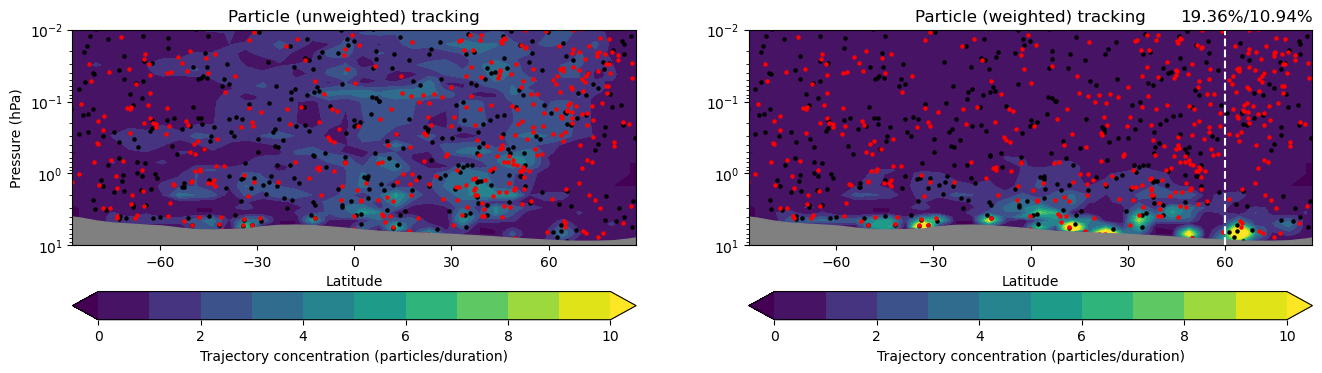

In [17]:
### Plotting  
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
(ax0, ax1) = axes

track_zonal_mean  = track.mean('lon', skipna=True)  # unweighted particle zonal mean (avg over longitude)
trackW_zonal_mean =trackW.mean('lon', skipna=True)  # weighted particle zonal mean (avg over longitude)

# Common background: zonal-mean concentration
ax0.set_title('Particle (unweighted) tracking')
# cf0 = ax0.contourf( track_zonal_mean['lat'],  track_zonal_mean['lev'],  track_zonal_mean, np.linspace(0, float( track_zonal_mean.max()), 10), extend='both')
cf0 = ax0.contourf( track_zonal_mean['lat'],  track_zonal_mean['lev'],  track_zonal_mean, np.arange(0,10+1,1), extend='both')

ax1.set_title('Particle (weighted) tracking')
# cf1 = ax1.contourf(trackW_zonal_mean['lat'], trackW_zonal_mean['lev'], trackW_zonal_mean, np.linspace(0, float(trackW_zonal_mean.max()), 10), extend='both')
cf1 = ax1.contourf(trackW_zonal_mean['lat'], trackW_zonal_mean['lev'], trackW_zonal_mean, np.arange(0,10+1,1), extend='both')

# One colorbar for both subplots
plt.colorbar(cf0, ax=ax0, orientation='horizontal', label='Trajectory concentration (particles/duration)')
plt.colorbar(cf1, ax=ax1, orientation='horizontal', label='Trajectory concentration (particles/duration)')

# Common axes styling
for ax in axes:
    ax.set_xlabel('Latitude')
    ax.set_xlim(-87, 87)
    ax.set_xticks([-60, -30, 0, 30, 60])
    ax.set_yscale('log')
    ax.set_ylim(10, 1e-2)
    if ax == ax0: ax0.set_ylabel('Pressure (hPa)')
    ax.scatter(       scptL,        scptP, s=5, color='k', marker="o")  # initial positions
    ax.scatter(ptlat[:, -1], ptlev[:, -1], s=5, color='r', marker="o")  # final positions
    ax.fill_between(ps['lat'], ps, y2=10, color='gray')  # topography (surface → 10 hPa)

### Particle cross rate calculation

### >>>>>> Mixing barrier latitude <<<<<< (modify as needed)
barrier_lat = 60 # default is 60N 
### >>>>>> Mixing barrier latitude <<<<<< (modify as needed) 

total_air_mass = 0
input_air_mass = 0
output_air_mass= 0

for ptsIdx in range(len(scptW)):
    for timeIdx in range(len(ptlat[0,:])):

        input_lat = scptL[ptsIdx].values 
        index_lat = np.abs(lat - input_lat).argmin()

        input_lev = scptP[ptsIdx].values
        index_lev = np.abs(lev - input_lev).argmin()

        input_lat2= ptlat[ptsIdx,timeIdx].values
        index_lat2= np.abs(lat - input_lat2).argmin()

        input_lev2= ptlev[ptsIdx,timeIdx].values
        index_lev2= np.abs(lev - input_lev2).argmin()

        if lat[index_lat] > barrier_lat and not np.isnan(scptW[ptsIdx]):
            total_air_mass = total_air_mass + scptW[ptsIdx]
        
        if lat[index_lat] > barrier_lat and lat[index_lat2] < barrier_lat and not np.isnan(scptW[ptsIdx]):
            output_air_mass = output_air_mass + scptW[ptsIdx]
        
        if lat[index_lat] < barrier_lat and lat[index_lat2] > barrier_lat and not np.isnan(scptW[ptsIdx]):
            input_air_mass = input_air_mass + scptW[ptsIdx]

inside_cross_rate  = (output_air_mass / total_air_mass * 1e2)
outside_cross_rate = ( input_air_mass / total_air_mass * 1e2)

# Common axes styling
for ax in axes:
    if ax == ax1: 
        ax.axvline(x=barrier_lat, color='w', linestyle='--')
        ax.set_title('%.2f%%/%.2f%%' %(inside_cross_rate,outside_cross_rate),loc='right')

plt.show()